In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from datasets import load_dataset
import re
import random
from tensorflow import keras


In [2]:
# Reproducibility: set global seeds
import os
import random
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


In [4]:
df = pd.read_csv("ranking_dataset.csv")

In [5]:
pairs = []
for i in range(len(df)):
  vals = []
  ranks = []
  for j in range(10):
    vals.append(df.iloc[i, j])
  for k in range(10, 20):
    ranks.append(df.iloc[i, k])
  pairs.append((vals, ranks))

print(pairs[0])

([np.int64(542), np.int64(67), np.int64(876), np.int64(414), np.int64(26), np.int64(335), np.int64(620), np.int64(924), np.int64(950), np.int64(113)], [np.int64(5), np.int64(1), np.int64(7), np.int64(4), np.int64(0), np.int64(3), np.int64(6), np.int64(8), np.int64(9), np.int64(2)])


In [6]:
train = pairs[:7000]
eval = pairs[7000:8500]
test = pairs[8500:]

In [7]:
def batches(pairs, batch_size):
    #random.shuffle(pairs)
    for i in range(0, len(pairs) - batch_size + 1, batch_size):

        batch = pairs[i: i + batch_size]

        inputs = []
        targets = []

        for i in batch:
            inputs.append(i[0])
            targets.append(i[1])

        yield tf.constant(inputs, dtype=tf.int32), tf.constant(targets, dtype=tf.int32)

In [ ]:
%pip install evaluate

In [8]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, d_model):
        super().__init__()

        pe = np.zeros((10, d_model))

        positions = np.arange(10).reshape(-1, 1)
        dims = np.arange(0, d_model, 2).reshape(1, -1)

        div_term = np.power(10000, dims/d_model)

        pe[:,0::2] = np.sin(positions/div_term)
        pe[:,1::2] = np.cos(positions/div_term)

        self.pe = tf.constant(pe[np.newaxis, :, :], dtype=tf.float32)

    def call(self, x):
        return x + self.pe[:, :tf.shape(x)[1], :]



In [24]:
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_k = d_model//num_heads

        self.W_Q = tf.keras.layers.Dense(d_model)
        self.W_K = tf.keras.layers.Dense(d_model)
        self.W_V = tf.keras.layers.Dense(d_model)

        self.W = tf.keras.layers.Dense(d_model)

    def split(self, x, batchsize):
        x = tf.reshape(x, (batchsize, -1, self.num_heads, self.d_k))

        return tf.transpose(x, perm=[0, 2, 1, 3])
        #(batch, num_heads, 10, d_k)

    def computation(self, Q, K, V):
        # Q @ K^T
        scores  = tf.matmul(Q, K, transpose_b=True)
        # divide by sqrt(d_k)
        scores = scores/tf.math.sqrt(tf.cast(self.d_k, tf.float32))
        weights = tf.nn.softmax(scores, axis=-1)
        output = tf.matmul(weights, V)
        return output, weights

    def call(self, x):
        batch_size = tf.shape(x)[0]
        Q = self.split(self.W_Q(x), batch_size)
        K = self.split(self.W_K(x), batch_size)
        V = self.split(self.W_V(x), batch_size)

        attn_out, weights = self.computation(Q, K, V)
        #(batch, heads, seq, d_k)
        #can use weights returned here to visualise attention later

        attn_out = tf.transpose(attn_out, perm=[0, 2, 1, 3])
        #(batch, seq, heads, d_k)

        attn_out = tf.reshape(attn_out, (batch_size, -1, self.num_heads * self.d_k))
        #(batch, seq, d_model)

        return self.W(attn_out), weights


class Encoder(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, f_dim):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ff1 = tf.keras.layers.Dense(f_dim, activation='relu')
        self.ff2 = tf.keras.layers.Dense(d_model)
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.norm2 = tf.keras.layers.LayerNormalization()

    def call(self, x):
        attn_out, weights = self.attention(x)
        x = self.norm1(x + attn_out)

        ff_out = self.ff2(self.ff1(x))
        x = self.norm2(x + ff_out) #residual connection

        return x


In [10]:
d_model = 128
num_heads = 8
f_dim = 256

batchsize = 100
EPOCHS = 25
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(axis = -1)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

In [ ]:
print(train[:5])
print(batches(train[:5], 5))

In [ ]:
for Xtrain, ytrain in batches(train[:2], 2):
    print("X =", Xtrain)
    print("y =", ytrain)
    break

X = tf.Tensor(
[[542  67 876 414  26 335 620 924 950 113]
 [378  14 210 954 231 572 315 295 567 706]], shape=(2, 10), dtype=int32)
y = tf.Tensor(
[[5 1 7 4 0 3 6 8 9 2]
 [5 0 1 9 2 7 4 3 6 8]], shape=(2, 10), dtype=int32)


In [11]:
inputs = tf.keras.Input(shape=(10,1))
emb = tf.keras.layers.Dense(d_model)(inputs)
emb = PositionalEncoding(d_model)(emb)
out = Encoder(d_model, num_heads, f_dim)(emb)
out = tf.keras.layers.Dropout(0.3)(out)
out = tf.keras.layers.Dense(10, activation = 'softmax')(out)
Transformer = tf.keras.Model(inputs, out)

#emb.shape

In [14]:
import evaluate

losstrack = []
acctrack = []

for epoch in range(1, EPOCHS + 1):

    accuracy_metric = evaluate.load("accuracy")

    #training

    train_loss, steps = 0, 0
    for Xtrain, ytrain in batches(train, batchsize):
        with tf.GradientTape() as tape:
            predictions = Transformer(Xtrain, training=True)
            loss = loss_fn(ytrain, predictions)
        grads = tape.gradient(loss, Transformer.trainable_variables)
        optimizer.apply_gradients(zip(grads, Transformer.trainable_variables))
        train_loss += loss.numpy()
        steps += 1

    losstrack.append(train_loss/steps)

    #validation

    for Xval, yval in batches(eval, batchsize):
        predictions = Transformer(Xval, training=False)
        preds = tf.argmax(predictions, axis=-1).numpy().flatten()
        targets = yval.numpy().flatten()
        accuracy_metric.add_batch(predictions=preds, references=targets)

    val_acc = accuracy_metric.compute()["accuracy"] * 100
    acctrack.append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS}  Loss: {train_loss/steps:.4f}  Val Acc: {val_acc:.2f}%")





/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Epoch 01/25  Loss: 1.7034  Val Acc: 42.57%
Epoch 02/25  Loss: 1.3349  Val Acc: 46.25%
Epoch 03/25  Loss: 1.2709  Val Acc: 48.55%
Epoch 04/25  Loss: 1.2852  Val Acc: 48.93%
Epoch 05/25  Loss: 1.2381  Val Acc: 49.08%
Epoch 06/25  Loss: 1.2317  Val Acc: 48.07%
Epoch 07/25  Loss: 1.2165  Val Acc: 48.97%
Epoch 08/25  Loss: 1.2135  Val Acc: 49.24%
Epoch 09/25  Loss: 1.2247  Val Acc: 48.85%
Epoch 10/25  Loss: 1.1995  Val Acc: 49.21%
Epoch 11/25  Loss: 1.2101  Val Acc: 47.43%
Epoch 12/25  Loss: 1.1928  Val Acc: 48.65%
Epoch 13/25  Loss: 1.2020  Val Acc: 49.70%
Epoch 14/25  Loss: 1.2096  Val Acc: 48.65%
Epoch 15/25  Loss: 1.1972  Val Acc: 50.66%
Epoch 16/25  Loss: 1.2212  Val Acc: 45.63%
Epoch 17/25  Loss: 1.1986  Val Acc: 49.88%
Epoch 18/25  Loss: 1.1834  Val Acc: 46.52%
Epoch 19/25  Loss: 1.1864  Val Acc: 49.27%
Epoch 20/25  Loss: 1.2032  Val Acc: 47.34%
Epoch 21/25  Loss: 1.2035  Val Acc: 50.45%
Epoch 22/25  Loss: 1.1883  Val Acc: 50.67%
Epoch 23/25  Loss: 1.2061  Val Acc: 48.10%
Epoch 24/25

In [15]:
# Save final weights and optional full model export
import os
os.makedirs('./checkpoints/encoder', exist_ok=True)
Transformer.save_weights('./checkpoints/encoder/transformer_weights.weights.h5')



In [16]:
Transformer.load_weights('./checkpoints/encoder/transformer_weights.weights.h5')

In [17]:
import matplotlib.pyplot as plt

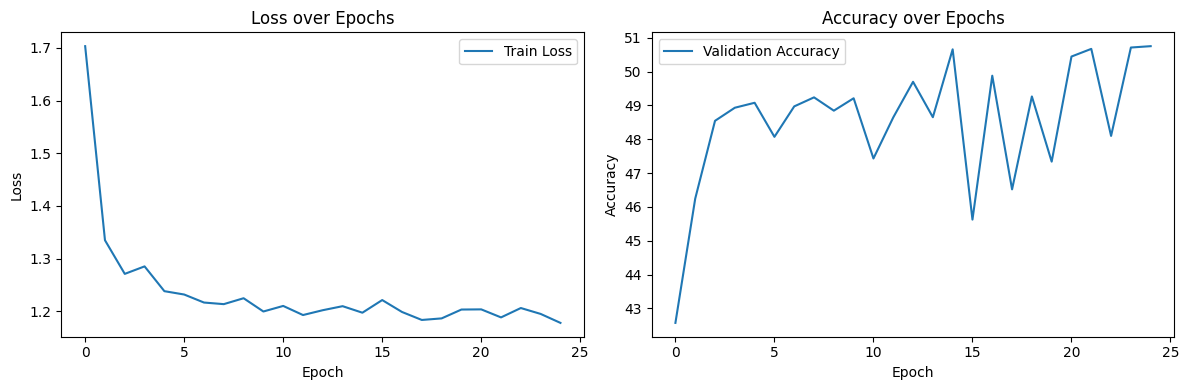

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losstrack, label='Train Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acctrack, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
#testing

for Xtest, ytest in batches(test, batchsize):
        predictions = Transformer(Xtest, training=False)
        preds = tf.argmax(predictions, axis=-1).numpy().flatten()
        targets = ytest.numpy().flatten()
        accuracy_metric.add_batch(predictions=preds, references=targets)

test_acc = accuracy_metric.compute()["accuracy"] * 100
print(f"\nTest Acc: {test_acc:.2f}%")


Test Acc: 50.67%


In [21]:
for X,y  in batches(train[:1],1):
  pred = Transformer(X, training=False)
  pred = tf.argmax(pred, axis=-1)

print(pred.numpy()[0])
print(y.numpy()[0])

print(np.mean(pred.numpy()[0] == y.numpy()[0]))

[5 1 8 4 0 3 6 8 9 1]
[5 1 7 4 0 3 6 8 9 2]
0.8


In [22]:
accs = []

for X, y in batches(train[:100], 1):
    pred = Transformer(X, training=False)
    pred = tf.argmax(pred, axis=-1)

    accs.append(
        np.mean(pred.numpy()[0] == y.numpy()[0])
    )

print(np.mean(accs))
print(np.min(accs))
print(np.max(accs))

0.495
0.2
0.9


In [ ]:
pred_probs = Transformer(X, training=False)

for i in range(10):
    print(pred_probs[0, i].numpy())

[1.5554073e-05 3.6152082e-03 4.1865893e-02 1.1494854e-01 2.0461588e-01
 2.8035063e-01 2.1726254e-01 1.1564110e-01 2.1683205e-02 1.4803641e-06]
[4.7286966e-01 4.0087575e-01 1.1203947e-01 1.0060288e-02 3.3026547e-03
 4.4972141e-04 2.6977455e-04 7.9367979e-05 5.2337702e-05 9.6512326e-07]
[2.8856283e-07 4.2031679e-05 1.0512250e-03 1.0540087e-03 5.0693867e-03
 1.6563140e-02 1.3061418e-01 2.3852696e-01 5.8173513e-01 2.5343591e-02]
[6.0358168e-05 2.2798724e-02 1.3002217e-01 2.1785516e-01 2.8795177e-01
 2.0402001e-01 9.6137665e-02 3.5772100e-02 5.3814300e-03 6.1487606e-07]
[8.8529950e-01 9.8981336e-02 1.4253100e-02 9.4562973e-04 3.8554121e-04
 5.7616759e-05 4.4809203e-05 1.5614396e-05 1.5954405e-05 1.0832039e-06]
[1.6100712e-04 6.9765702e-02 2.0263875e-01 2.8053737e-01 2.6460567e-01
 1.2013874e-01 4.5241684e-02 1.4782396e-02 2.1282127e-03 4.4347360e-07]
[7.5029820e-06 1.2414515e-03 1.8756196e-02 6.6319212e-02 1.4630228e-01
 2.6678976e-01 2.7549139e-01 1.7968598e-01 4.5403335e-02 2.9512012e-06]